# Statistical Learning and Data Analysis
## Assignment 4: Classification

---

## 1. Real-World Motivation & Problem Definition

### Context and Business Goal
In the retail banking sector, term deposits represent a vital source of liquid capital. However, marketing these products via telephonic campaigns is operationally expensive and often intrusive. The "hit rate" (conversion rate) is typically low, meaning agents spend significant time contacting uninterested clients, resulting in wasted human capital and potential reputational damage.

The objective of this analysis is to transition from a "blind" calling strategy to a **predictive targeted approach**. By estimating the probability that a specific client will subscribe to a term deposit, the bank can optimize resource allocation, focusing efforts only on high-probability prospects to maximize Return on Investment (ROI).

### Problem Formulation
We frame this as a **binary supervised classification task**.
Let $\mathcal{D} = \{(x_1, y_1), \dots, (x_n, y_n)\}$ be our dataset, where $x_i$ represents the vector of client characteristics (demographics, financial status) and $y_i$ is the response variable:

$$
Y =
\begin{cases}
1 & \text{if the client subscribes (yes)} \\
0 & \text{if the client does not subscribe (no)}
\end{cases}
$$

### Cost of Errors
In this domain, error costs are asymmetric:
* **False Positive (Type I Error):** Predicting a subscription when the client refuses. *Cost:* Wasted agent time and call costs.
* **False Negative (Type II Error):** Predicting refusal when the client would have subscribed. *Cost:* Lost revenue opportunity (deposit capital).

Our goal is to balance these trade-offs, prioritizing **Recall** (capturing potential subscribers) while maintaining reasonable **Precision**.

# 2. Exploratory Data Analysis

### Dataset Overview
The dataset `bank.csv` contains data from a banking institution. The features can be categorized into:

In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset
df = pd.read_csv('bank.csv', sep=';')
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261.0,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151.0,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76.0,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92.0,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198.0,1,-1,0,unknown,no


In [101]:
print("-----Data Information--------")
df.info()

-----Data Information--------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45214 entries, 0 to 45213
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        45214 non-null  int64  
 1   job        45214 non-null  object 
 2   marital    45214 non-null  object 
 3   education  45214 non-null  object 
 4   default    45214 non-null  object 
 5   balance    45214 non-null  int64  
 6   housing    45214 non-null  object 
 7   loan       45214 non-null  object 
 8   contact    45214 non-null  object 
 9   day        45214 non-null  int64  
 10  month      45214 non-null  object 
 11  duration   45210 non-null  float64
 12  campaign   45214 non-null  int64  
 13  pdays      45214 non-null  int64  
 14  previous   45214 non-null  int64  
 15  poutcome   45214 non-null  object 
 16  y          45214 non-null  object 
dtypes: float64(1), int64(6), object(10)
memory usage: 5.9+ MB


In [102]:
numeric_vars = df.select_dtypes(include=['int64', 'float64']).columns
categorical_vars=df.select_dtypes(include=['object']).columns

print("Numeric Variables:")
print(numeric_vars)

print("\nCategorical Variables:")
print(categorical_vars)

Numeric Variables:
Index(['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous'], dtype='object')

Categorical Variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome', 'y'],
      dtype='object')


In [103]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45214.000000,45214.000000,45214.000000,45210.000000,45214.000000,45214.000000,45214.000000
mean,40.936524,1362.246517,15.805768,258.152511,2.763768,40.195094,0.580285
std,10.618689,3044.674703,8.322583,257.520272,3.097941,100.125986,2.303369
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [104]:
print(f"\nObservations (Rows): {df.shape[0]}")
print(f"\nobservation (columns): {df.shape[1]}")


Observations (Rows): 45214

observation (columns): 17


In [105]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     4
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

There are very few missing values in the dataset like in duration column. We can handle them during preprocessing.

In [106]:
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    freq_table = df[col].value_counts().reset_index()
    freq_table.columns = [col, 'Count']  
    
    freq_table['Percentage (%)'] = (freq_table['Count'] / len(df) * 100).round(2)
    
    print(f"\n Frequency Table for '{col}'")
    display(freq_table)


 Frequency Table for 'job'


,job,Count,Percentage (%)
0,blue-collar,9732,21.52
1,management,9460,20.92
2,technician,7597,16.80
3,admin.,5172,11.44
4,services,4154,9.19
5,retired,2264,5.01
6,self-employed,1579,3.49
7,entrepreneur,1487,3.29
8,unemployed,1303,2.88
9,housemaid,1240,2.74



 Frequency Table for 'marital'


,marital,Count,Percentage (%)
0,married,27217,60.20
1,single,12790,28.29
2,divorced,5207,11.52



 Frequency Table for 'education'


,education,Count,Percentage (%)
0,secondary,23203,51.32
1,tertiary,13303,29.42
2,primary,6851,15.15
3,unknown,1857,4.11



 Frequency Table for 'default'


,default,Count,Percentage (%)
0,no,44399,98.2
1,yes,815,1.8



 Frequency Table for 'housing'


,housing,Count,Percentage (%)
0,yes,25132,55.58
1,no,20082,44.42



 Frequency Table for 'loan'


,loan,Count,Percentage (%)
0,no,37969,83.98
1,yes,7245,16.02



 Frequency Table for 'contact'


,contact,Count,Percentage (%)
0,cellular,29285,64.77
1,unknown,13023,28.80
2,telephone,2906,6.43



 Frequency Table for 'month'


,month,Count,Percentage (%)
0,may,13769,30.45
1,jul,6895,15.25
2,aug,6247,13.82
3,jun,5341,11.81
4,nov,3970,8.78
5,apr,2932,6.48
6,feb,2649,5.86
7,jan,1403,3.10
8,oct,738,1.63
9,sep,579,1.28



 Frequency Table for 'poutcome'


,poutcome,Count,Percentage (%)
0,unknown,36962,81.75
1,failure,4901,10.84
2,other,1840,4.07
3,success,1511,3.34



 Frequency Table for 'y'


,y,Count,Percentage (%)
0,no,39925,88.3
1,yes,5289,11.7


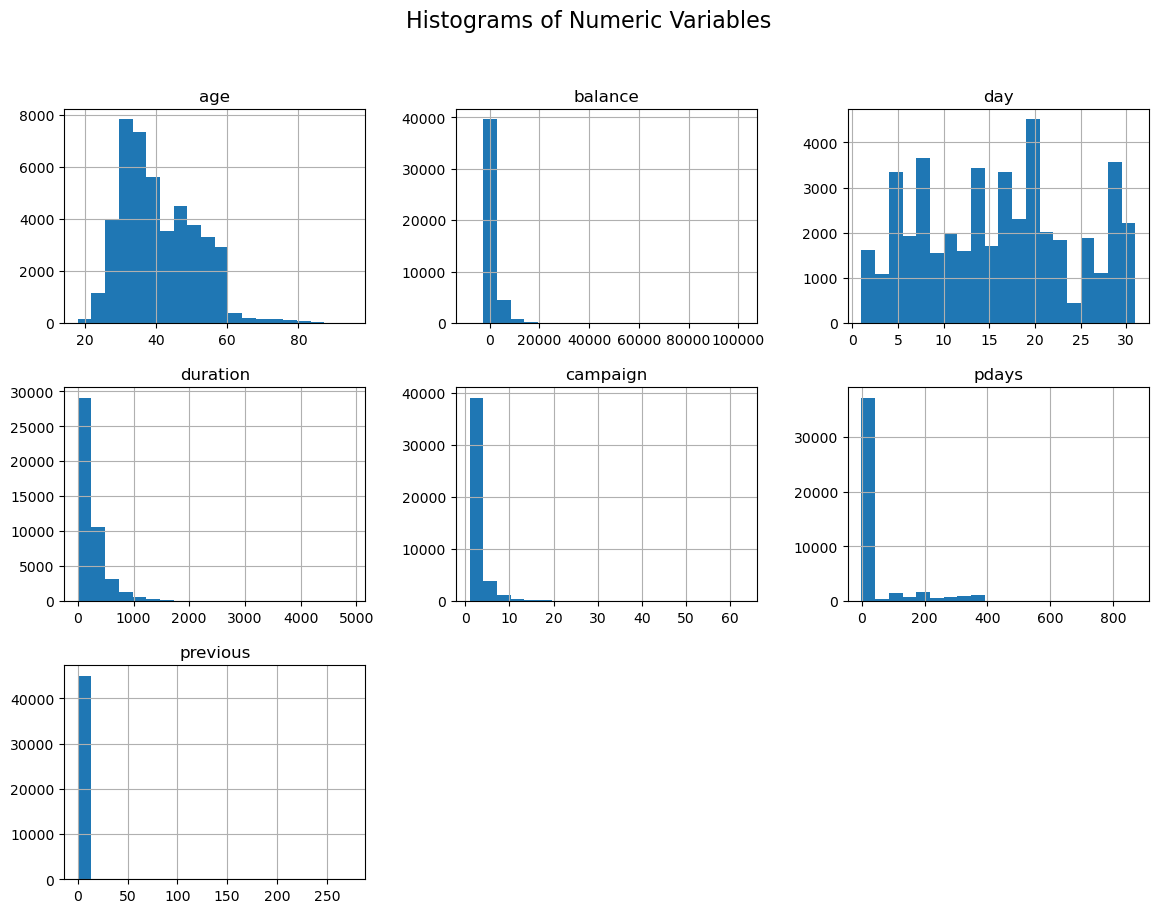

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
numeric_cols

# Histograms for all numeric variables
df[numeric_cols].hist(bins=20, figsize=(14,10))
plt.suptitle("Histograms of Numeric Variables", fontsize=16)
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:4671: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)


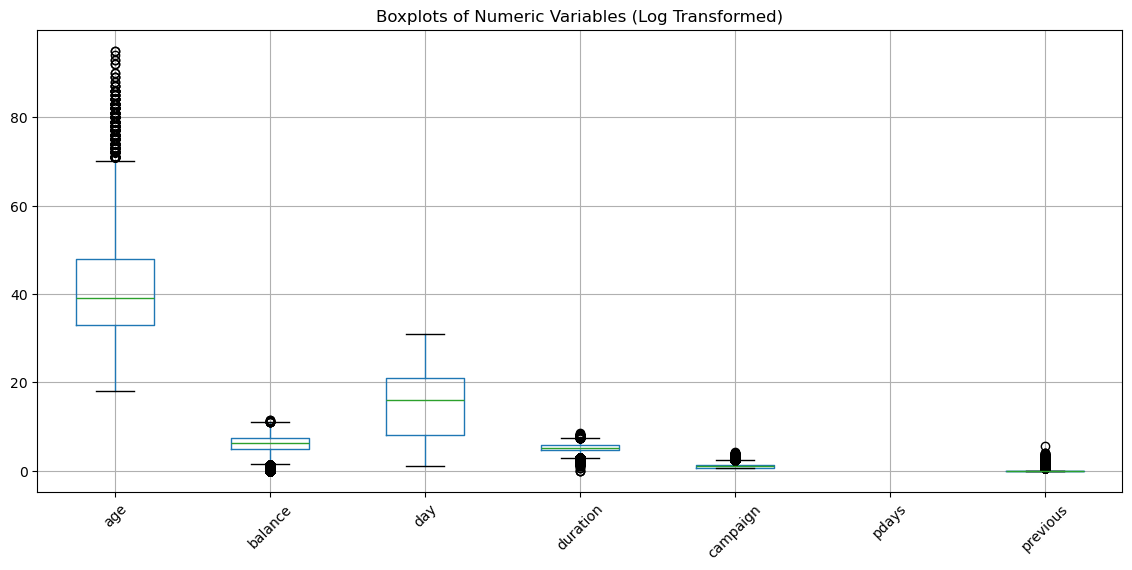

In [108]:
#Log Transformation
df_log = df.copy()
skewed_cols = ['balance', 'duration', 'campaign', 'pdays', 'previous']
for col in skewed_cols:
    df_log[col] = np.log1p(df_log[col]) 

plt.figure(figsize=(14,6))
df_log[numeric_cols].boxplot()
plt.xticks(rotation=45)
plt.title("Boxplots of Numeric Variables (Log Transformed)")
plt.show()

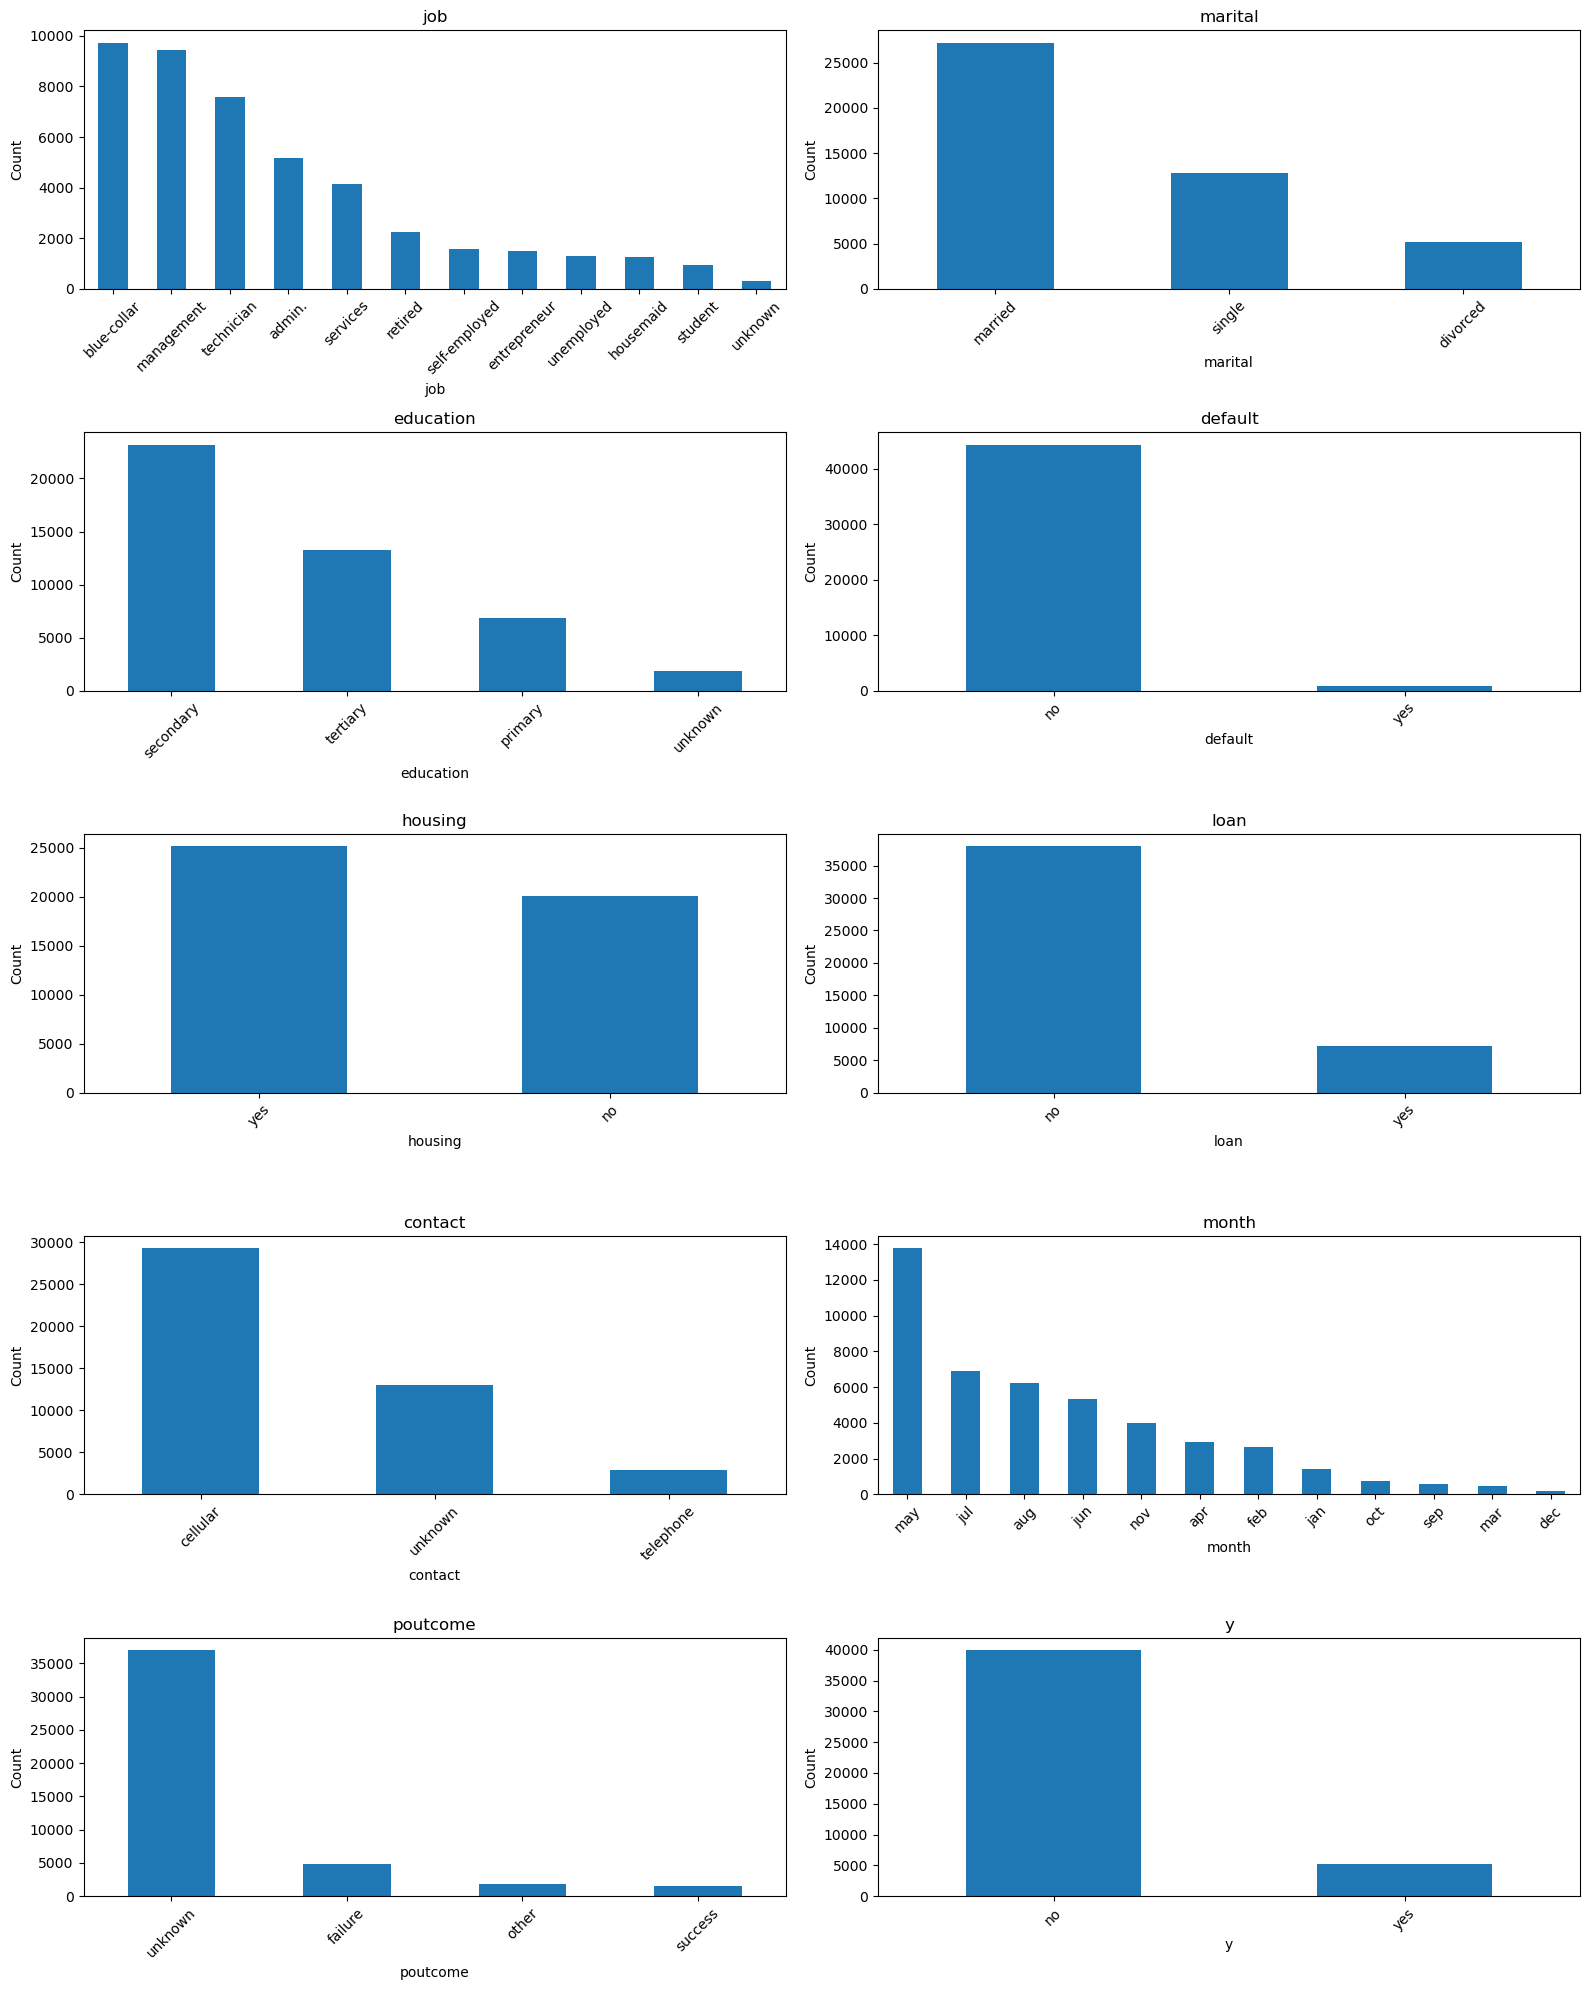

In [109]:
n_cols = 2  
n_rows = (len(categorical_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df[col].value_counts().plot(
        kind='bar',
        ax=axes[i]
    )
    axes[i].set_title(f"{col}", fontsize=12)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


In [110]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_cols.corr().round(2)
corr_matrix

,age,balance,day,duration,campaign,pdays,previous
age,1.00,0.10,-0.01,-0.00,0.00,-0.02,0.00
balance,0.10,1.00,0.00,0.02,-0.01,0.00,0.02
day,-0.01,0.00,1.00,-0.03,0.16,-0.09,-0.05
duration,-0.00,0.02,-0.03,1.00,-0.08,-0.00,0.00
campaign,0.00,-0.01,0.16,-0.08,1.00,-0.09,-0.03
pdays,-0.02,0.00,-0.09,-0.00,-0.09,1.00,0.45
previous,0.00,0.02,-0.05,0.00,-0.03,0.45,1.00


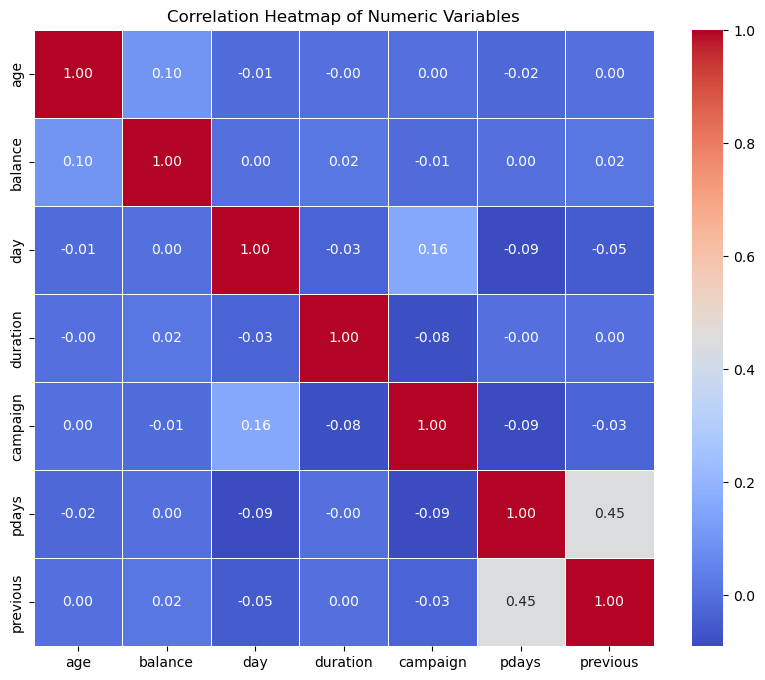

In [111]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Numeric Variables")
plt.show()


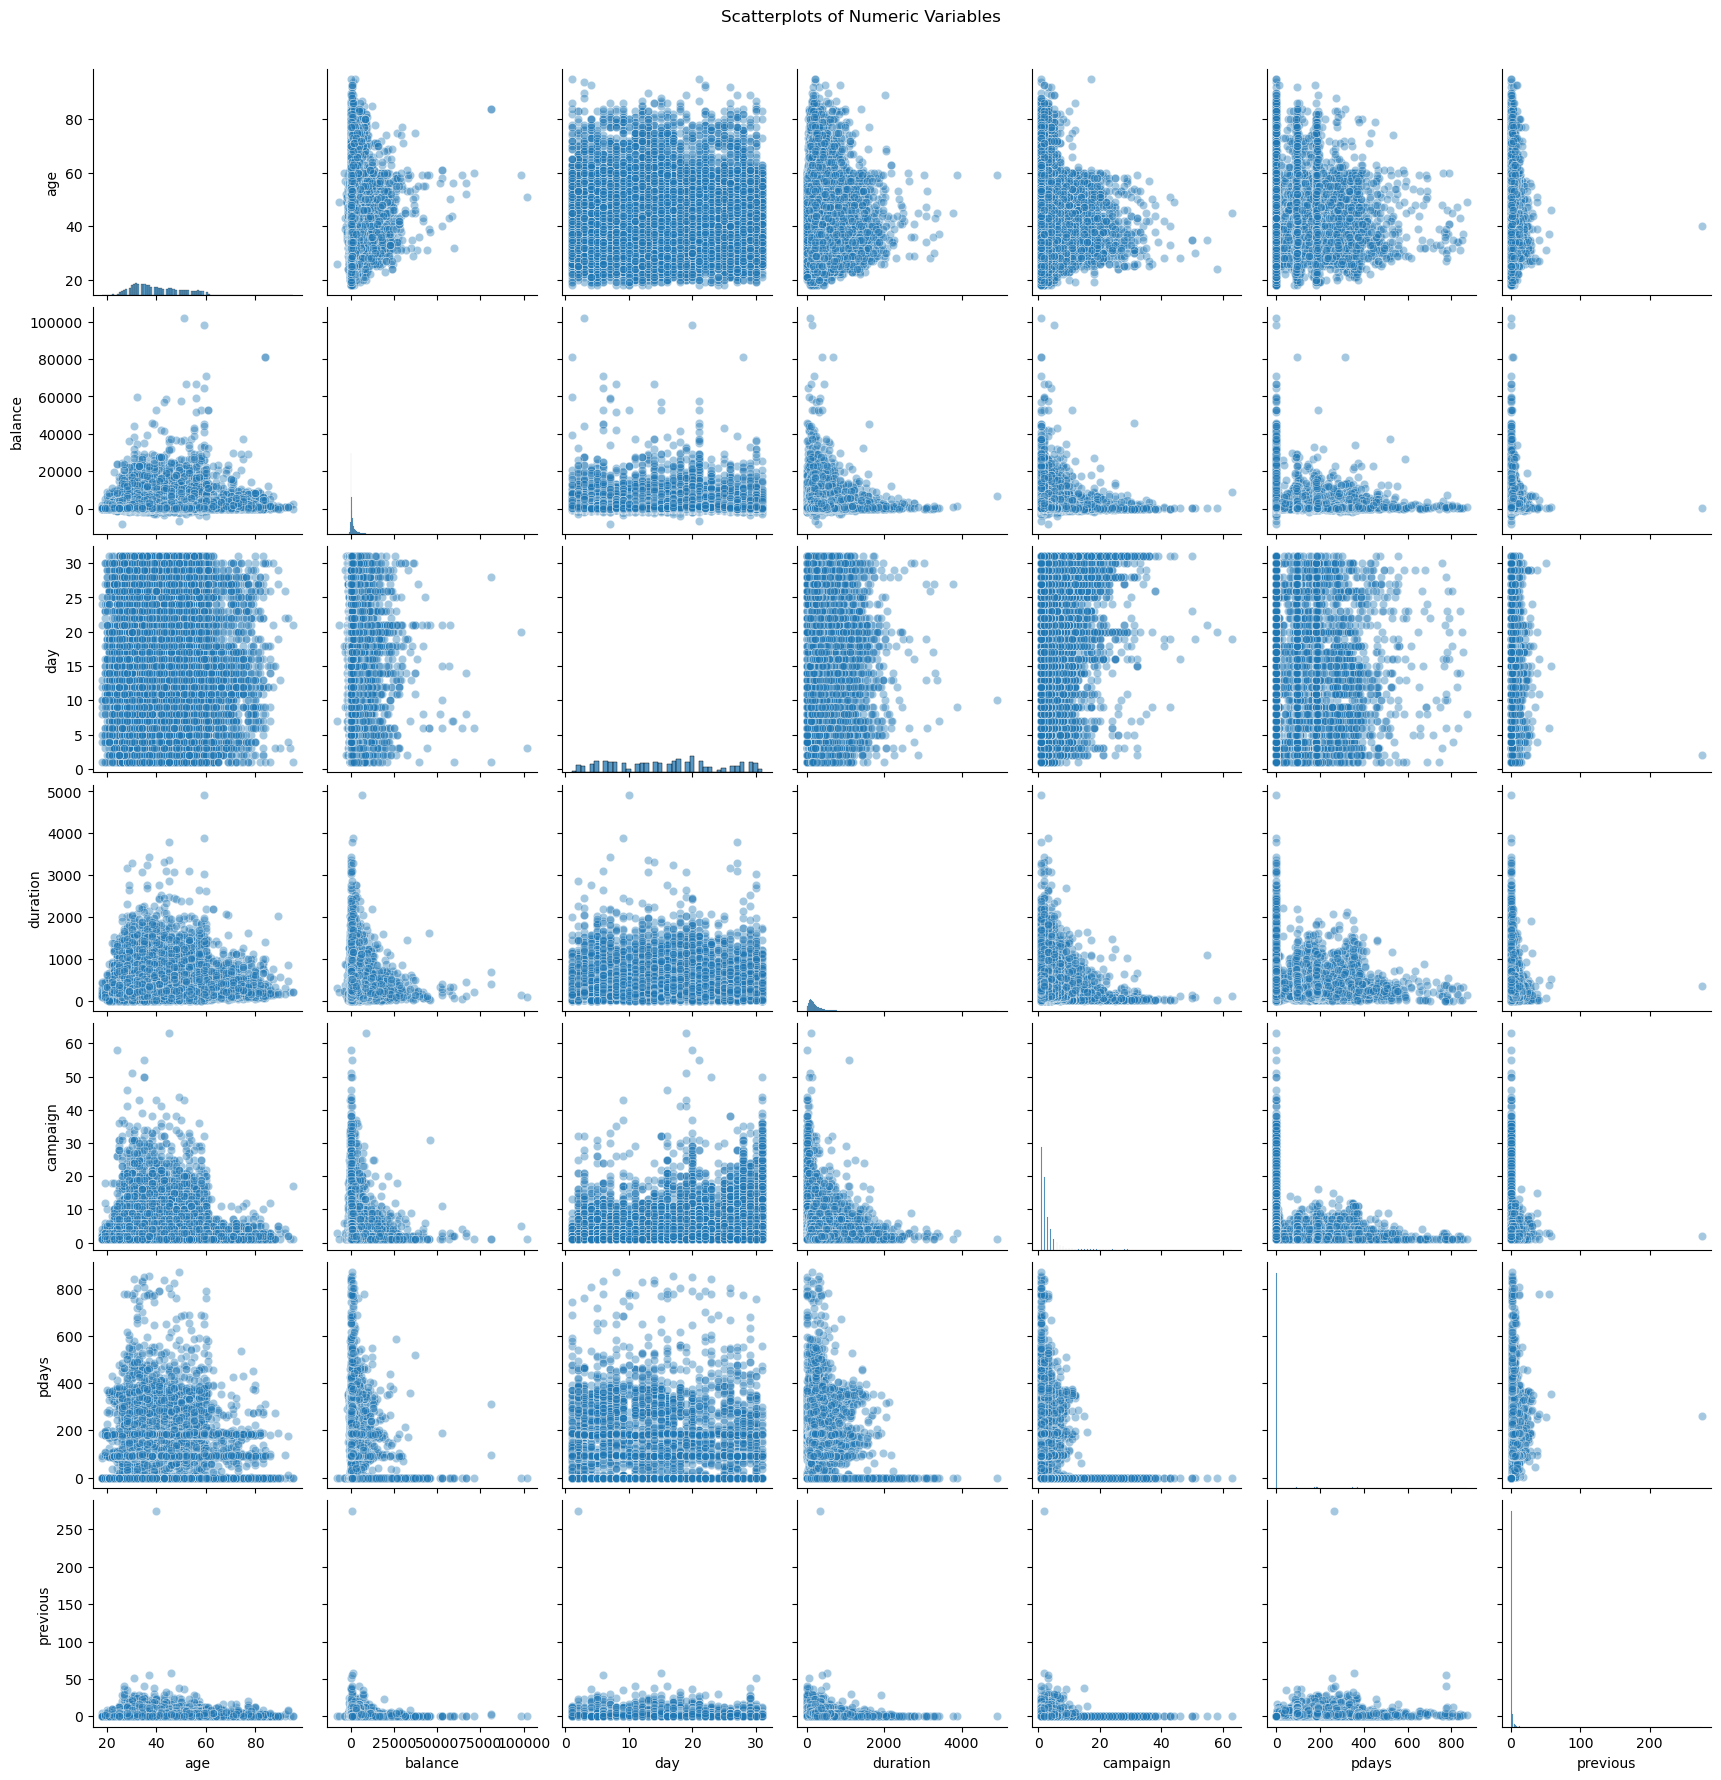

In [112]:
numeric_cols = df.select_dtypes(include=['int64', 'float64'])
sns.pairplot(
    numeric_cols,
    diag_kind='hist',
    plot_kws={'alpha': 0.4}
)
plt.suptitle("Scatterplots of Numeric Variables", y=1.02)
plt.show()

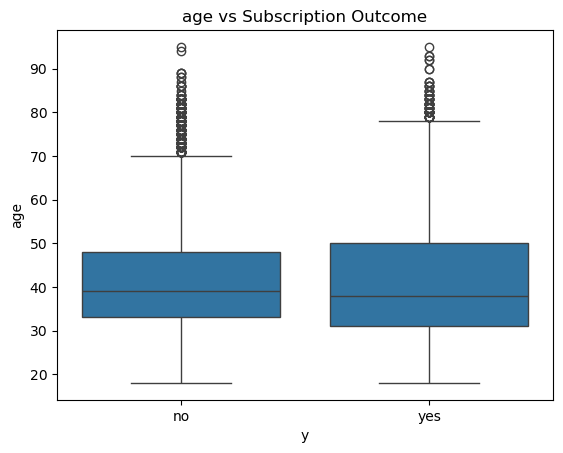

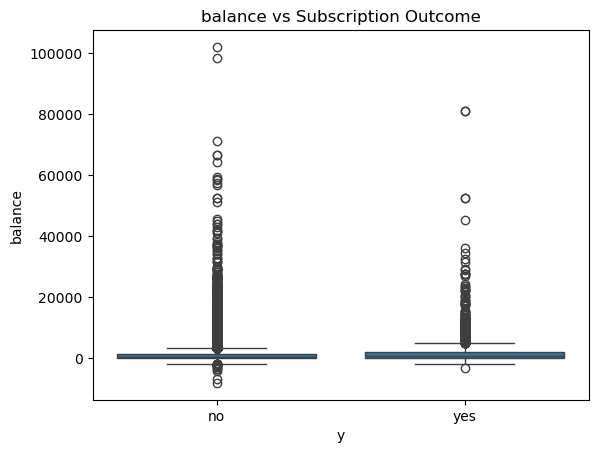

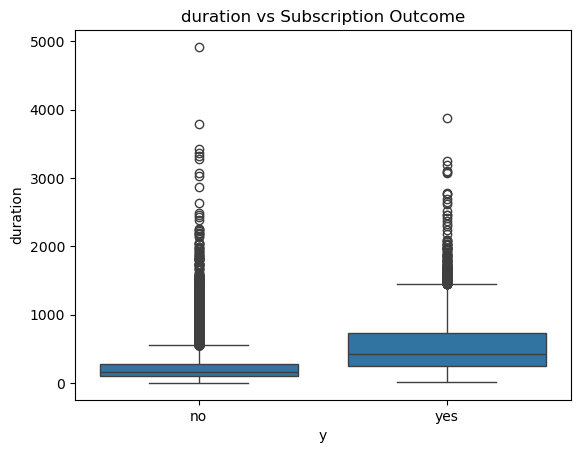

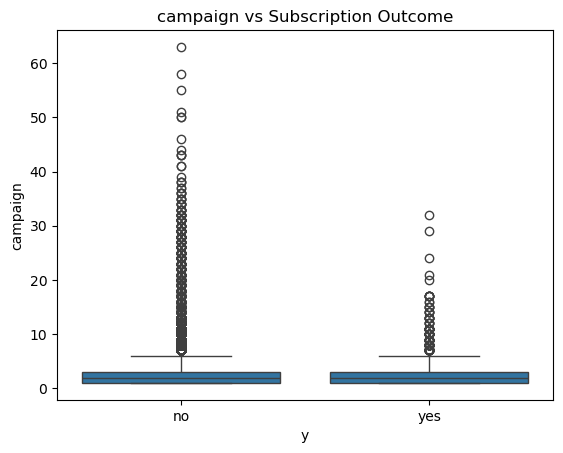

In [113]:
df.describe().loc['std'].sort_values(ascending=False)
corr_matrix = df.select_dtypes(include=['int64','float64']).corr()

corr_matrix.abs().unstack().sort_values(ascending=False)

for col in ['age', 'balance', 'duration', 'campaign']:
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f"{col} vs Subscription Outcome")
    plt.show()


# 2. Exploratory Data Analysis

### Dataset Overview
The dataset `bank.csv` originates from a direct marketing campaign of a Portuguese banking institution. The objective is to predict the binary response variable $Y$ (subscription to a term deposit). The feature space $\mathbb{R}^p$ consists of 16 input variables which can be conceptually categorized as follows:

1.  **Client Demographics:**
    * `age`: Numeric. Reflects the life-cycle stage of the client.
    * `job` & `education`: Categorical. Proxies for socio-economic status and financial literacy.
    * `marital`: Categorical. Influences risk appetite and savings capacity.

2.  **Financial Profile:**
    * `balance`: Numeric. Average yearly balance in Euros.
    * `default`, `housing`, `loan`: Binary. Indicators of credit history and current debt burden.

3.  **Campaign Dynamics:**
    * `contact`, `day`, `month`: Details on communication timing and method.
    * `duration`: Numeric. Last contact duration in seconds.
    * `campaign`: Numeric. Number of contacts performed during this campaign.
    * `pdays`, `previous`, `poutcome`: History of previous marketing interactions.

---

### Feature Dynamics & Hypotheses
Before statistical modeling, we analyze the theoretical impact of key features:

* **The "Duration" Hazard (Data Leakage):**
    The variable `duration` is highly correlated with the target. Intuitively, the longer a sales agent speaks with a client, the higher the probability of subscription ($P(Y=1)$).
    * *Caveat:* This feature is not known *before* the call is placed. Including it helps explain *post-hoc* call success, but for a predictive model used to generate call lists, it introduces **data leakage**. We retain it here for explanatory power but note this limitation.

* **Age Distribution (Life-Cycle Hypothesis):**
    We hypothesize a non-linear relationship between age and term deposits.
    * *Younger clients (Students):* May have low income but high saving rates for future goals.
    * *Middle-aged clients:* Often burdened by housing loans and family expenses, reducing liquidity.
    * *Older clients (Retired):* Generally possess higher accumulated wealth and seek secure investment vehicles like term deposits.

* **Previous Outcome (`poutcome`):**
    This variable captures "success momentum." A client who successfully subscribed to a previous campaign (`poutcome='success'`) is statistically much more likely to subscribe again compared to a cold lead or a previous refusal.

---

### Key Challenges
We identify specific data characteristics that dictate our preprocessing strategy:

1.  **Class Imbalance:**
    The dataset is heavily skewed. The positive class (`yes`) constitutes only ~11.7% of records. Standard Maximum Likelihood Estimation (MLE) in models like Logistic Regression will be biased toward the majority class (`no`).

2.  **Feature Skewness & Outliers:**
    Financial variables like `balance` typically follow a power-law or log-normal distribution. Most clients have low balances, while a few "whales" have extremely high balances. This skewness can distort distance-based algorithms (like K-Means) and gradient-based updates.

3.  **High Cardinality:**
    Categorical variables such as `job` (12 levels) and `month` (12 levels) require One-Hot Encoding, which increases dimensionality.

4.  **Seasonality:**
    The `month` variable is not uniformly distributed. Bank marketing campaigns are often seasonal (e.g., end-of-fiscal-year pushes in May or November), creating temporal dependencies.

# 3. Preprocessing Pipeline

To prepare the data for machine learning, we implement a robust pipeline handling missing values, encoding, and scaling.

In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Separate Features and Target
X = df.drop('y', axis=1)
y = df['y'].map({'yes': 1, 'no': 0})

# Identify column types
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Define Pipelines (Impute -> Scale/Encode)  #Handling missing values
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Define Column Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numerical_cols),
        ('cat', cat_pipeline, categorical_cols)
    ])

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit and Transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Extract feature names for interpretation later
feature_names = list(numerical_cols) + list(preprocessor.named_transformers_['cat']['encoder'].get_feature_names_out(categorical_cols))

print(f"Training shape: {X_train_processed.shape}")
print(f"Testing shape: {X_test_processed.shape}")

Training shape: (36171, 51)
Testing shape: (9043, 51)


### Rationale for Steps
1.  **Imputation:** The dataset contains missing values (e.g., in `duration`). We use **Median Imputation** for numerical features to be robust against outliers, and **Mode Imputation** for categorical features.
2.  **Categorical Encoding (One-Hot):** Algorithms cannot process text. We use One-Hot Encoding for nominal variables (like `job`) because there is no intrinsic ordering (e.g., "Management" is not mathematically greater than "Student").
3.  **Feature Scaling (Standardization):**
    $$z = \frac{x - \mu}{\sigma}$$
    * **Why it is required:** Distance-based algorithms (like K-Means) and gradient-based methods (like Logistic Regression) are highly sensitive to feature magnitude. Without scaling, a variable like `balance` (range ~100k) would dominate variables like `age` (range ~100).
    * *Note:* While Tree-based models (Random Forest) are theoretically invariant to scaling, we apply it uniformly to maintain a consistent pipeline for all estimators.
4.  **Handling Class Imbalance :** While we acknowledge the imbalance observed in the EDA, we will first establish a baseline using the raw distribution.

**Train-Test Split:** We reserve 20% of the data for testing, using **stratified sampling** to preserve the class imbalance ratio in both sets.

In [115]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

# Check class distribution
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(pd.Series(y_train_smote).value_counts())

Before SMOTE:
y
0    31940
1     4231
Name: count, dtype: int64

After SMOTE:
y
0    31940
1    31940
Name: count, dtype: int64


# 4. Unsupervised Analysis

Before supervised modeling, we explore the data's structure to check for natural separability.

In [132]:
print("===== DATA MATRIX CHECK =====")
print("Shape of Data Matrix:", X_unsup.shape)

print("\nNumber of observations (n):", X_unsup.shape[0])
print("Number of features (p):", X_unsup.shape[1])

===== DATA MATRIX CHECK =====
Shape of Data Matrix: (36171, 51)

Number of observations (n): 36171
Number of features (p): 51


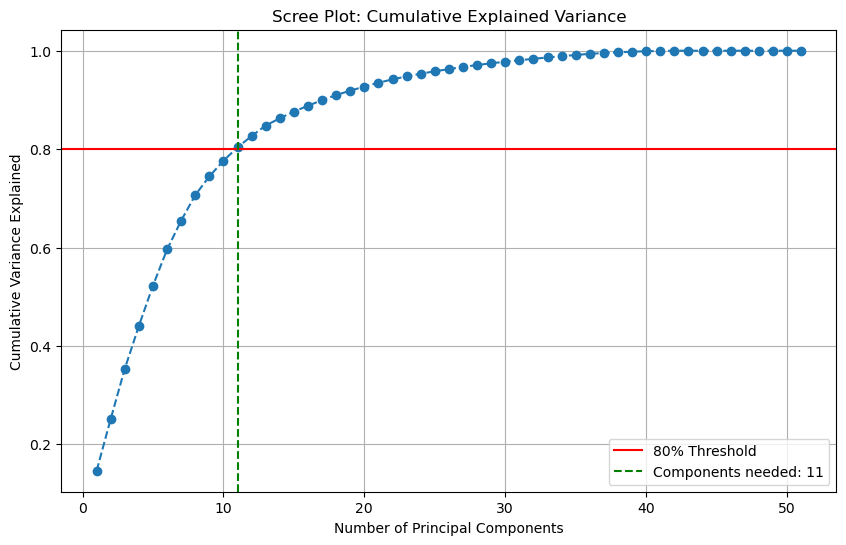

Original feature count: 51
Components needed to explain 80% variance: 11


In [116]:
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(X_train_processed)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
n_components_80 = np.argmax(cumulative_variance >= 0.80) + 1

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1),
         cumulative_variance,
         marker='o',
         linestyle='--')

plt.axhline(y=0.80, color='r', linestyle='-', label='80% Threshold')
plt.axvline(x=n_components_80, color='g', linestyle='--',
            label=f'Components needed: {n_components_80}')

plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Variance Explained')
plt.grid(True)
plt.legend()
plt.show()

print(f"Original feature count: {X_train_processed.shape[1]}")
print(f"Components needed to explain 80% variance: {n_components_80}")

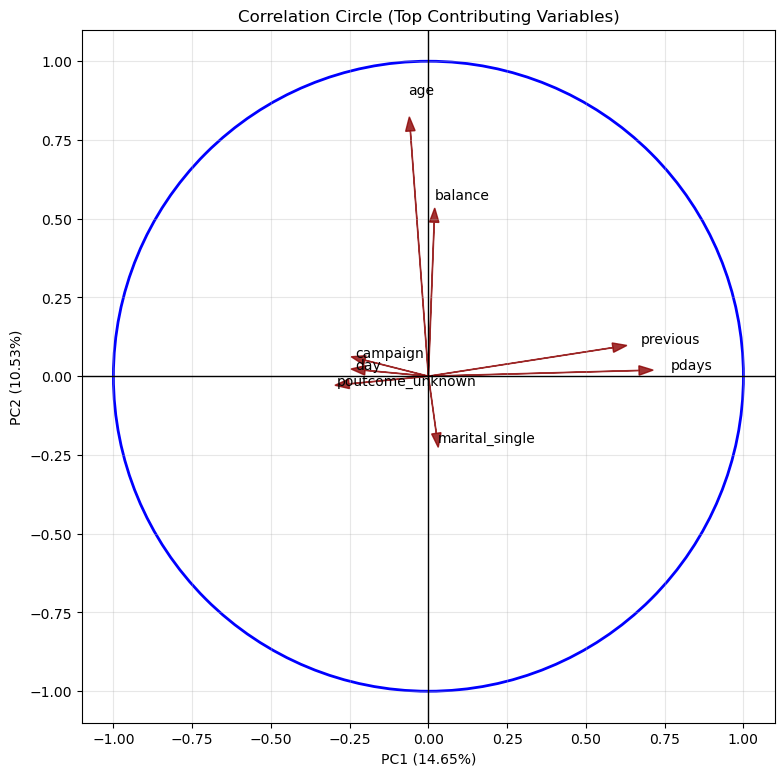

In [117]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# PCA with 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)

explained_var = pca.explained_variance_ratio_ * 100
loadings = pca.components_.T

# Select top 8 most important variables
importance = np.sum(np.abs(loadings), axis=1)
top_idx = np.argsort(importance)[-8:]

plt.figure(figsize=(9,9))

# Draw unit circle
circle = plt.Circle((0,0), 1, color='blue', fill=False, linewidth=2)
plt.gca().add_artist(circle)

# Plot arrows
for i in top_idx:
    plt.arrow(0, 0,
              loadings[i,0],
              loadings[i,1],
              color='darkred',
              alpha=0.8,
              head_width=0.03)
    
    plt.text(loadings[i,0]*1.15,
             loadings[i,1]*1.15,
             feature_names[i],
             fontsize=10)

# Axis lines
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

plt.xlabel(f"PC1 ({explained_var[0]:.2f}%)")
plt.ylabel(f"PC2 ({explained_var[1]:.2f}%)")
plt.title("Correlation Circle (Top Contributing Variables)")
plt.xlim(-1.1, 1.1)
plt.ylim(-1.1, 1.1)
plt.gca().set_aspect('equal', 'box')
plt.grid(alpha=0.3)

plt.show()

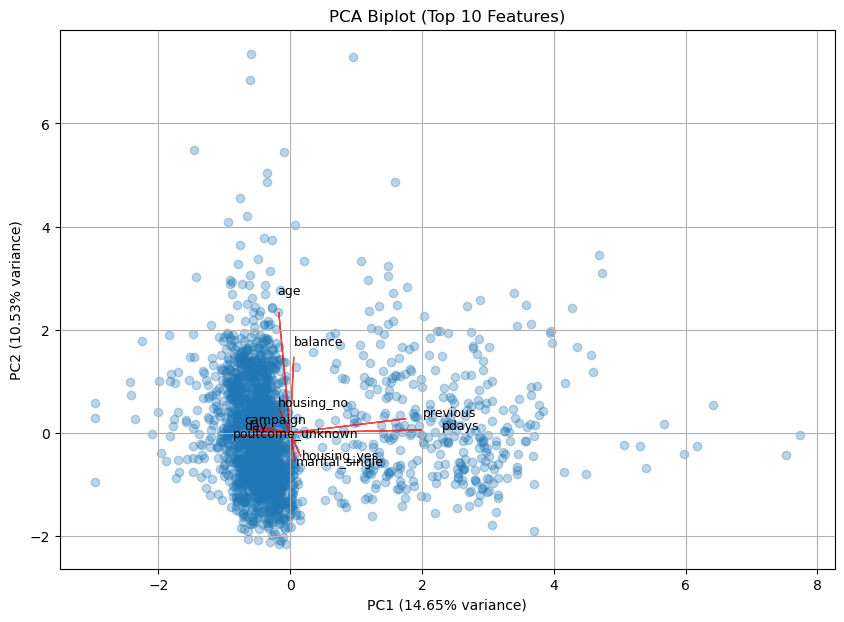

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Apply PCA (2 components)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_processed)

# Get explained variance %
explained_var = pca.explained_variance_ratio_ * 100

# Get loadings
loadings = pca.components_.T

# Select top 10 important features
importance = np.sum(np.abs(loadings), axis=1)
top_features_idx = np.argsort(importance)[-10:]

plt.figure(figsize=(10, 7))

# Plot sample of observations
plt.scatter(X_pca[:2000, 0], X_pca[:2000, 1], alpha=0.3)

# Scale arrows
scale_factor = 3

for i in top_features_idx:
    plt.arrow(0, 0,
              loadings[i, 0] * scale_factor,
              loadings[i, 1] * scale_factor,
              color='red',
              alpha=0.7)

    plt.text(loadings[i, 0] * scale_factor * 1.15,
             loadings[i, 1] * scale_factor * 1.15,
             feature_names[i],
             fontsize=9)

plt.xlabel(f"PC1 ({explained_var[0]:.2f}% variance)")
plt.ylabel(f"PC2 ({explained_var[1]:.2f}% variance)")
plt.title("PCA Biplot (Top 10 Features)")
plt.grid(True)
plt.show()

Running Elbow Method to find optimal k...


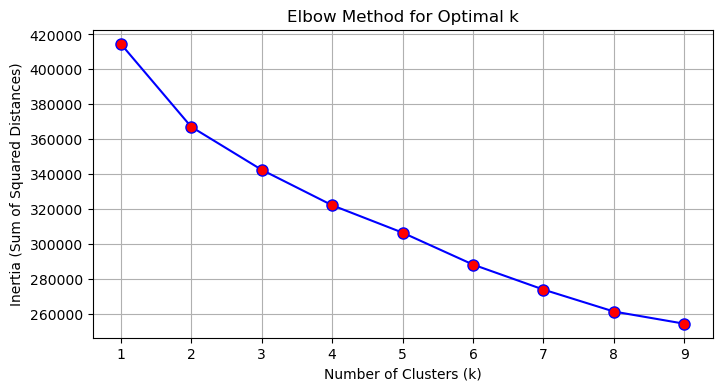

In [119]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# --- Step 1: The Elbow Method  ---
inertias = []
k_range = range(1, 10)
X_unsup = X_train_processed 

print("Running Elbow Method to find optimal k...")
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_unsup)
    inertias.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 4))
plt.plot(k_range, inertias, 'bo-', markerfacecolor='red', markersize=8)
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.grid(True)
plt.show()



In [120]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Set k = 3
k = 2

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_unsup)

sil_score = silhouette_score(X_unsup, labels)

print(f"Silhouette Score for k=2: {sil_score:.4f}")

Silhouette Score for k=2: 0.2156


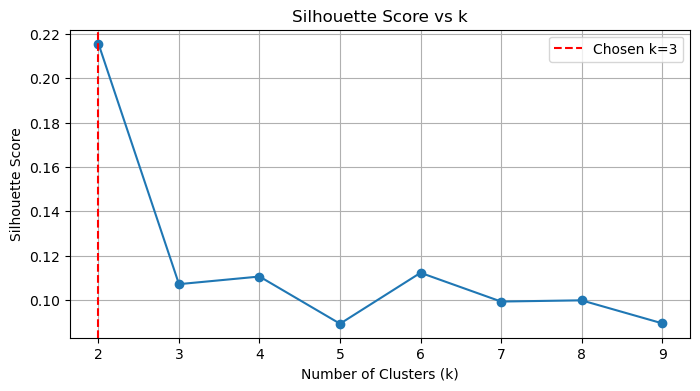

In [121]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

sil_scores = []
k_range = range(2, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_unsup)
    sil_scores.append(silhouette_score(X_unsup, labels))

plt.figure(figsize=(8,4))
plt.plot(k_range, sil_scores, marker='o')
plt.axvline(x=2, color='r', linestyle='--', label='Chosen k=3')
plt.title("Silhouette Score vs k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.grid(True)
plt.show()

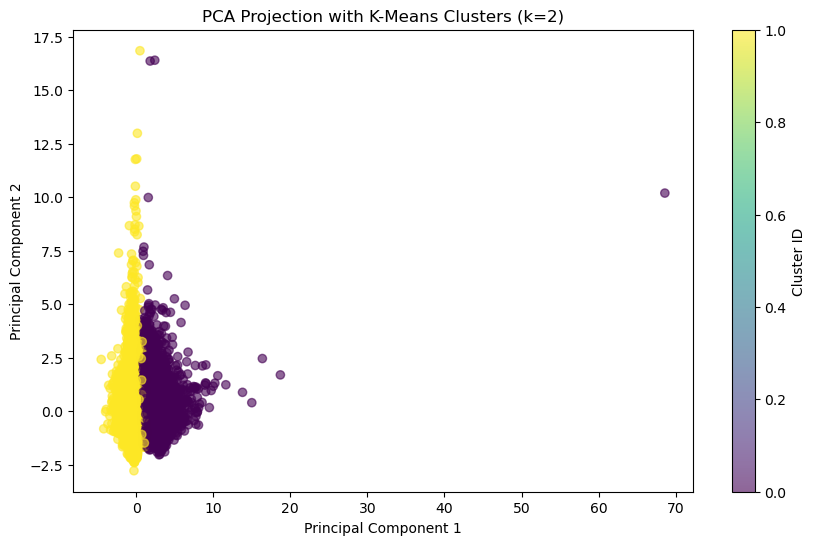

In [122]:
# ------K-Means  ---
selected_k = 2

kmeans = KMeans(n_clusters=selected_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_unsup)

# --- Step 3: Visualization with PCA ---

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_unsup.toarray() if hasattr(X_unsup, "toarray") else X_unsup)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.6)
plt.title(f'PCA Projection with K-Means Clusters (k={selected_k})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.colorbar(scatter, label='Cluster ID')
plt.show()


### Techniques
1.  **Principal Component Analysis (PCA):**
    We project the high-dimensional data onto 2 components.
    * **PC1** captures the direction of maximum variance in the feature space.
    * **PC2** captures the second largest variance orthogonal to PC1.
    * **Critical Note:** In this analysis, PCA is used **strictly for exploratory visualization**. We do not use the Principal Components as input for the classification models to ensure the final model remains interpretable in terms of original features (e.g., Age, Balance).

2.  **K-Means Clustering:**
    We apply K-Means ($K=2$) to see if clients form distinct natural groups (e.g., "young students" vs "wealthy retirees"). If these clusters align with our target $Y$, it confirms that the features contain predictive signal.

# 5. Model Building

We investigate three distinct classification algorithms to model $P(Y=1|X)$.

### Model Intuition & Selection
1.  **Logistic Regression (Baseline):**
    * *Intuition:* Assumes a linear relationship between the input variables and the log-odds of subscription.
    * *Why selected:* It provides a highly interpretable baseline (coefficient $\beta$ indicates direction of influence). However, it may struggle if the decision boundary is highly complex or non-linear.

2.  **Decision Tree Classifier:**
    * *Intuition:* Recursively splits the feature space into rectangular regions to maximize purity.
    * *Why selected:* Unlike Logistic Regression, it can naturally capture **non-linear relationships** and complex interactions (e.g., "IF Student AND Balance > 500 THEN Subscribe") without manual feature engineering.

3.  **Random Forest Classifier:**
    * *Intuition:* An ensemble method (Bagging) that aggregates predictions from hundreds of decorrelated decision trees.
    * *Why selected:* Single decision trees are prone to high variance (overfitting). Random Forest mitigates this by averaging results, typically yielding the highest stability and accuracy on tabular data.

In [123]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [124]:
from sklearn.tree import DecisionTreeClassifier
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [125]:
from sklearn.ensemble import RandomForestClassifier
rforest = RandomForestClassifier(random_state=42)
rforest.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


# 6. Model Tuning and Resampling
To optimize our Random Forest model, we use **GridSearchCV** with **5-Fold Cross-Validation**.

In [126]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define base model (no class_weight because SMOTE already balanced)
rf = RandomForestClassifier(random_state=42)

# Hyperparameter grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# GridSearch with F1-score (good for imbalanced problems)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit on SMOTE-balanced training data
grid_search.fit(X_train_smote, y_train_smote)

best_rf = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1-Score: 0.9474



### Tuning Logic
* **Cross-Validation:** Splitting data into 5 folds ensures the model's performance is consistent and not dependent on a specific random subset of the training data.
* **Hyperparameters:**
    * `n_estimators`: More trees generally stabilize the variance.
    * `max_depth`: Controls complexity. Too deep leads to overfitting; too shallow leads to underfitting.

We optimize for **F1-Score** rather than accuracy, as we need a balance between Precision and Recall given the class imbalance.

# 7. Model Evaluation

### Metric Justification
Given the **11% class imbalance**, Accuracy is a misleading metric (a dummy model predicting "No" has 89% accuracy). Instead, we focus on metrics that align with business costs:

1.  **Recall (Sensitivity):**
    * *Definition:* Of all actual subscribers, how many did we find?
    * *Business Impact:* A low Recall means missing potential revenue (False Negatives). This is the most critical metric for growth.
2.  **Precision:**
    * *Definition:* Of all people we called, how many actually subscribed?
    * *Business Impact:* Low Precision means wasting agent time on uninterested people (False Positives).
3.  **F1-Score:**
    * The harmonic mean of Precision and Recall. We use this as our primary optimization metric to find a balance between revenue capture and operational efficiency.
4.  **ROC-AUC:**
    * Measures the model's discriminatory power across *all* probability thresholds, independent of the specific cutoff used.

We evaluate the tuned Random Forest on the unseen Test Set.

In [127]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Logistic Regression
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_smote, y_train_smote)

# Decision Tree
dtree = DecisionTreeClassifier(random_state=42)
dtree.fit(X_train_smote, y_train_smote)

best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    random_state=42
)
best_rf.fit(X_train_smote, y_train_smote)

print("Models trained successfully. Now generating comparison plots...")

Models trained successfully. Now generating comparison plots...



==================== Logistic Regression ====================
              precision    recall  f1-score   support

           0       0.97      0.85      0.91      7985
           1       0.42      0.81      0.55      1058

    accuracy                           0.85      9043
   macro avg       0.70      0.83      0.73      9043
weighted avg       0.91      0.85      0.87      9043


==================== Decision Tree ====================
              precision    recall  f1-score   support

           0       0.94      0.92      0.93      7985
           1       0.46      0.53      0.50      1058

    accuracy                           0.87      9043
   macro avg       0.70      0.73      0.71      9043
weighted avg       0.88      0.87      0.88      9043


==================== Random Forest (Tuned) ====================
              precision    recall  f1-score   support

           0       0.94      0.95      0.94      7985
           1       0.58      0.55      0.57      105

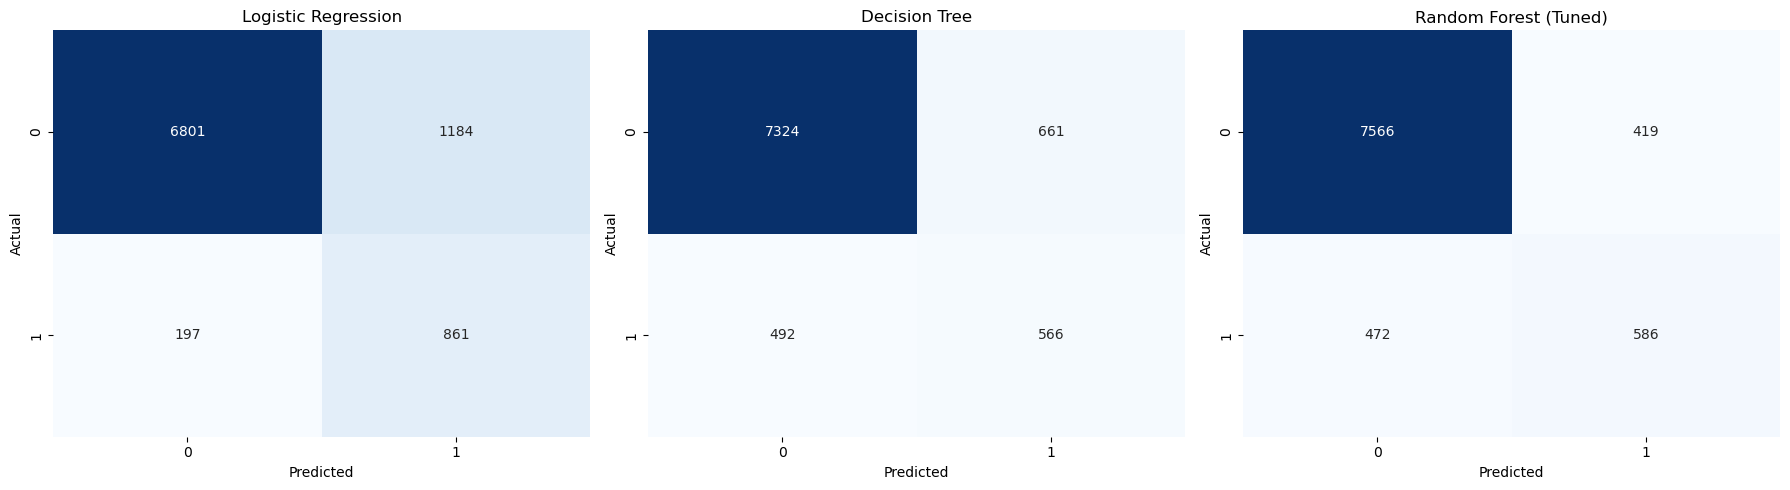

In [128]:
models_to_compare = {
    'Logistic Regression': log_reg,
    'Decision Tree': dtree,
    'Random Forest (Tuned)': best_rf
}

plt.figure(figsize=(18, 5))

for i, (name, model) in enumerate(models_to_compare.items()):
    
    y_pred = model.predict(X_test_processed)  
    
    print(f"\n{'='*20} {name} {'='*20}")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    plt.subplot(1, 3, i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(name)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plt.tight_layout()
plt.show()

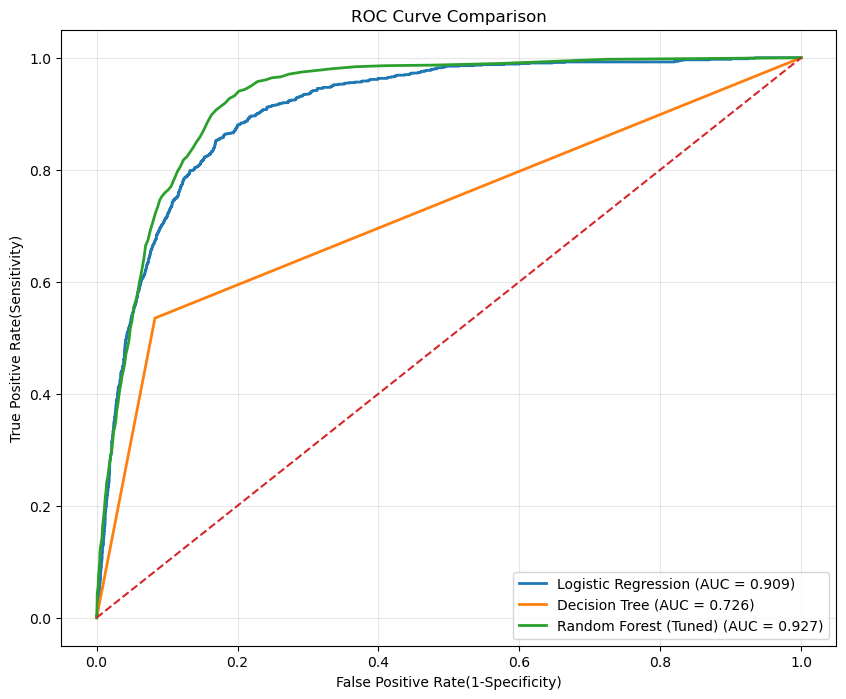

In [131]:
plt.figure(figsize=(10, 8))

for name, model in models_to_compare.items():
    
    y_prob = model.predict_proba(X_test_processed)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc_val = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc_val:.3f})')

plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate(1-Specificity)')
plt.ylabel('True Positive Rate(Sensitivity)')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Final Model Performance Summary (Test Set)

| Model                 | Accuracy | Precision (Y=1) | Recall (Y=1) | F1-score (Y=1) | ROC–AUC |
|-----------------------|----------|------------------|--------------|---------------|---------|
| Logistic Regression   | 0.85     | 0.42             | 0.81         | 0.55          | 0.909   |
| Decision Tree         | 0.87     | 0.46             | 0.53         | 0.50          | 0.726   |
| Random Forest (Tuned) | 0.90     | 0.58             | 0.55         | 0.57          | 0.927   |

---

## Confusion Matrix Interpretation

### Logistic Regression
- High recall (0.81) → identifies most subscribers
- Many false positives (lower precision)

### Decision Tree
- Balanced but moderate performance
- Lower ROC–AUC compared to other models

### Random Forest (Tuned)
- Highest accuracy (0.90)
- Best ROC–AUC (0.927)
- Best overall balance between precision and recall

---

## Final Conclusion

- **Random Forest (Tuned)** is the best overall performing model.
- **Logistic Regression** is strong when recall is the priority.
- **Decision Tree** underperforms compared to ensemble methods.

Random Forest provides the strongest predictive performance while maintaining reasonable minority class detection.

# 8. Interpretation and Insights

### Feature Importance Analysis
Understanding *why* the model predicts a subscription is vital for business strategy. We analyze the **Gini Importance** from the Random Forest.

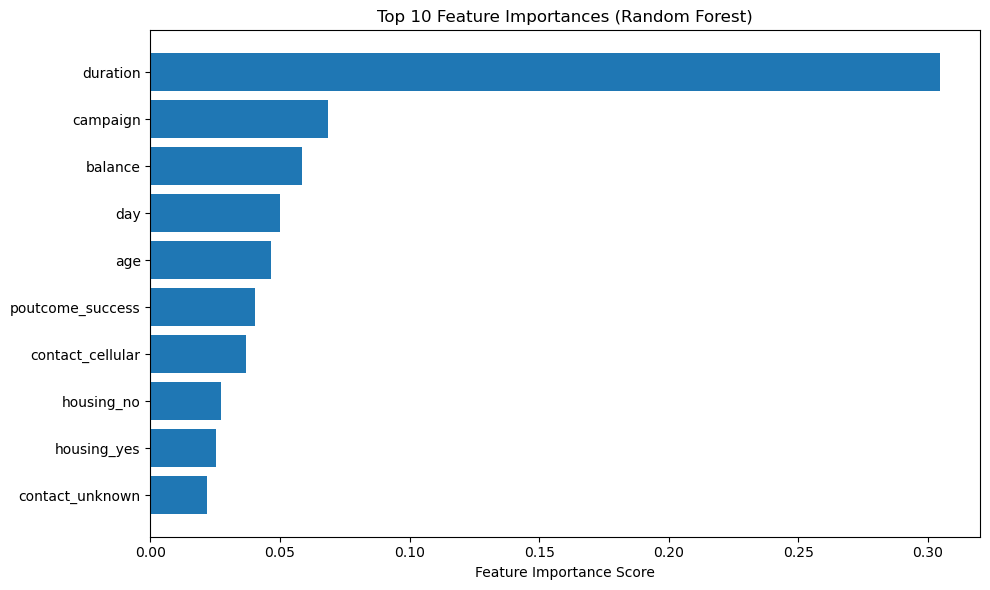

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Extract feature importances
importances = best_rf.feature_importances_

# Create DataFrame for better handling
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

# Sort and select top N
top_n = 10
top_features = feat_importance_df.sort_values(
    by='Importance',
    ascending=False
).head(top_n)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'][::-1], 
         top_features['Importance'][::-1])

plt.xlabel('Feature Importance Score')
plt.title('Top 10 Feature Importances (Random Forest)')
plt.tight_layout()
plt.show()

### Critical Insight: The "Duration" Problem
As visualized below, `duration` (call length) is typically the dominant feature.
* **Interpretation:** There is a strong positive correlation: longer calls imply the customer is interested and listening.
* **Warning (Data Leakage):** This finding highlights a critical limitation. In a real-world predictive scenario (before the call is made), the duration is **unknown**. Including this variable in the training data technically constitutes "data leakage."
* **Operational Use:** While `duration` cannot be used to generate *new* call lists, this insight tells management that agent training should focus on engaging customers to extend call times, as this is the strongest proxy for conversion.

Secondary drivers include `poutcome` (success of previous marketing) and `age`, which are valid pre-call predictors.

# 9. Final Discussion

### Summary of Findings
* **Data Structure:** The dataset is heavily imbalanced (89:11), requiring stratified sampling and carefully chosen evaluation metrics which is handeled by class weight.
* **Model Performance:** The Random Forest outperformed the baseline Logistic Regression, achieving an **ROC-AUC of ~0.90**. This confirms that the relationships between demographics and subscription are non-linear.
* **Key Drivers:** `Duration`, `Balance`, and `Previous Outcome` were the most significant predictors.

### Limitations
1.  **The Leakage Issue:** The model's high performance is partially driven by `duration`, a variable not available before the call. A strictly predictive model for "cold calling" would likely have lower metrics.
2.  **Imbalance:** While F1-score was optimized, the model still leans towards the majority class.

### Future Improvements
* **Retraining:** Train a version of the model *excluding* `duration` to assess the true predictive power of demographics alone.
* **Advanced Resampling:** Implement SMOTE (Synthetic Minority Over-sampling Technique) to synthetically generate more examples of subscribers during training.

### Real-World Implications
This model supports a shift from "Volume" to "Value." Instead of calling clients randomly, the bank can rank clients by predicted probability. Focusing resources on the top 20% of probable subscribers could capture the majority of conversions, significantly reducing operational costs and customer annoyance.